# Shallow LSTM Benchmark with Optuna & Symlog

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.0 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau
import optuna

SEED = 42
DATA_PATH = Path("Merged_Dataset_yoy.csv")
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
DEFAULT_LOOKBACK_DAYS = 365

MAX_EPOCHS = 100
PATIENCE = 15
TRAIN_YEAR_CUTOFF = 2020
VALID_YEAR_CUTOFF = 2022
OPTUNA_TRIALS = 50

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, torch.get_num_threads() // 2))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data Processing (Baseline)

In [3]:
def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = 365):
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        df = pd.read_csv("Merged_Dataset_yoy.csv")

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    # Derived company-specific features (size-neutral transforms)
    df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()
    exclude_cols = {"Date", "Company", "year", "has_targets"} | set(PREDICTION_TARGETS)
    feature_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            year_end_date = year_end_row["Date"]

            prior_year_records = year_end_records[
                (year_end_records["Company"] == company) & (year_end_records["year"] == year - 1)
            ]
            if prior_year_records.empty:
                continue

            prior_row = prior_year_records.iloc[0]
            window_start = year_end_date - pd.Timedelta(days=lookback_days)
            window = company_data[(company_data["Date"] > window_start) & (company_data["Date"] <= year_end_date)].copy()

            if len(window) < 200:
                continue

            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            static_cols = ["MC_MIB", "MC_MID", "MC_SMALL"]
            static_data = window[static_cols].iloc[-1].to_numpy(dtype=np.float32)

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": window[feature_cols].to_numpy(dtype=np.float32),
                "static_data": static_data,
                **{f"current_{t.lower()}": year_end_row[t] for t in PREDICTION_TARGETS},
                **{f"prior_{t.lower()}": prior_row[t] for t in PREDICTION_TARGETS},
            })

    data_records = []
    for seq in sequences:
        for target_name in PREDICTION_TARGETS:
            current_val = seq[f"current_{target_name.lower()}"]
            prior_val = seq[f"prior_{target_name.lower()}"]
            if pd.isna(current_val) or pd.isna(prior_val):
                continue

            label_value = (current_val - prior_val) / (np.abs(prior_val) + 1e-8)

            data_records.append({
                "company": seq["company"], "year": seq["year"], "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label_value,
                "window_data": seq["window_data"],
                "static_data": seq["static_data"]
            })

    return pd.DataFrame(data_records), feature_cols

data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH, lookback_days=DEFAULT_LOOKBACK_DAYS)

def split_by_year_dynamic(df: pd.DataFrame):
    if df.empty:
        raise ValueError("The dataset is empty. Check if DEFAULT_LOOKBACK_DAYS is too small.")

    available_years = sorted(df["year"].unique())
    print(f"Available years in dataset: {available_years}")

    # Use fixed cutoffs from constants
    train_cutoff = TRAIN_YEAR_CUTOFF
    valid_cutoff = VALID_YEAR_CUTOFF

    train_set = df[df["year"] <= train_cutoff].copy()
    val_set = df[(df["year"] > train_cutoff) & (df["year"] <= valid_cutoff)].copy()
    test_set = df[df["year"] > valid_cutoff].copy()

    print(f"Train: <= {train_cutoff} ({len(train_set)} samples)")
    print(f"Validation: {train_cutoff+1}-{valid_cutoff} ({len(val_set)} samples)")
    print(f"Test: > {valid_cutoff} ({len(test_set)} samples)")

    # Check if any split is empty
    if train_set.empty:
        print("WARNING: Train set is empty. Falling back to dynamic split.")
        if len(available_years) >= 3:
            valid_cutoff = available_years[-2]
            train_cutoff = available_years[-3]
            train_set = df[df["year"] <= train_cutoff].copy()
            val_set = df[(df["year"] > train_cutoff) & (df["year"] <= valid_cutoff)].copy()
            test_set = df[df["year"] > valid_cutoff].copy()
        elif len(available_years) == 2:
            print("WARNING: Only 2 years available. Using the last year for BOTH Validation and Test.")
            train_year = available_years[0]
            eval_year = available_years[1]
            train_set = df[df["year"] <= train_year].copy()
            val_set = df[df["year"] == eval_year].copy()
            test_set = df[df["year"] == eval_year].copy()
        else:
            raise ValueError("Not enough years to split the data. At least 2 years are required.")

    return train_set, val_set, test_set

# Split the data dynamically
train_data, val_data, test_data = split_by_year_dynamic(data_df)

# Initialize and fit the scaler safely
scaler = StandardScaler()

if train_data.empty:
    print("ERROR: train_data is empty after the split. Cannot fit the scaler.")
else:
    train_windows = np.vstack(train_data["window_data"].values)
    scaler.fit(train_windows)
    print("Success: StandardScaler fitted correctly.")

# Calculate max sequence length safely
if not data_df.empty:
    max_seq_length = max(len(row) for row in data_df["window_data"])
    print(f"Max sequence length found: {max_seq_length}")

Available years in dataset: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train: <= 2020 (3915 samples)
Validation: 2021-2022 (929 samples)
Test: > 2022 (980 samples)
Success: StandardScaler fitted correctly.
Max sequence length found: 260


## Enhanced Pipeline Setup (Symlog, RobustScaler, Packing)

In [4]:
SELECTED_FEATURES = [
    'Close_logret', 'Volume_log',
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume',
    'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close',
    'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv',
    'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom',
    'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume'
]
STATIC_FEATURES = ['MC_MIB', 'MC_MID', 'MC_SMALL']
STATIC_DIM = len(STATIC_FEATURES)
selected_indices = [feature_cols.index(f) for f in SELECTED_FEATURES]
print(f"Selected temporal features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")
print(f"Static features ({len(STATIC_FEATURES)}): {STATIC_FEATURES}")

improved_data_df = data_df.copy()

# SYMLOG TRANSFORMATION instead of Winsorization
idx_value = improved_data_df["target"].isin(PREDICTION_TARGETS)
y_val = improved_data_df.loc[idx_value, "label_value"]
improved_data_df.loc[idx_value, "label_value"] = np.sign(y_val) * np.log1p(np.abs(y_val))

# Use the dynamic split function to prevent empty dataframes
train_data_imp, val_data_imp, test_data_imp = split_by_year_dynamic(improved_data_df)

robust_scaler = RobustScaler()

# Safely fit the RobustScaler only if data is present
if train_data_imp.empty:
    print("ERROR: train_data_imp is empty after the dynamic split. Check input data.")
else:
    train_windows_imp = np.vstack([row[:, selected_indices] for row in train_data_imp["window_data"]])
    robust_scaler.fit(train_windows_imp)
    print("Success: RobustScaler fitted correctly.")

def collate_fn_improved(batch):
    batch.sort(key=lambda x: x[2], reverse=True)
    sequences = [x[0] for x in batch]
    targets = torch.stack([x[1] for x in batch])
    lengths = torch.tensor([x[2] for x in batch])
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, lengths

Available years in dataset: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train: <= 2020 (3915 samples)
Validation: 2021-2022 (929 samples)
Test: > 2022 (980 samples)
Success: RobustScaler fitted correctly.


## Model Definitions

In [5]:
class ShallowLSTMClassifier(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = 1, dropout: float = 0.2, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x: torch.Tensor, static: torch.Tensor = None) -> torch.Tensor:
        lstm_out, _ = self.lstm(x)
        hidden = self.dropout(lstm_out[:, -1, :])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits

class ImprovedShallowLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = 1, dropout: float = 0.2, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits


## Helpers for Optuna and Evaluation

In [6]:
def extract_mtl_df(df: pd.DataFrame) -> pd.DataFrame:
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        window_data = group.iloc[0]["window_data"]
        year_end_date = group.iloc[0]["year_end_date"]
        static_data = group.iloc[0]["static_data"]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                label_value[i] = t_row.iloc[0]["label_value"]
        mtl_records.append({
            "company": company, "year": year, "year_end_date": year_end_date,
            "window_data": window_data, "static_data": static_data,
            "label_value": label_value
        })
    return pd.DataFrame(mtl_records)

def extract_mtl_df_debug(df: pd.DataFrame, group_name: str = "") -> pd.DataFrame:
    mtl_records = []
    debug_info = {t: {"found": 0, "nan": 0} for t in PREDICTION_TARGETS}
    for (company, year), group in df.groupby(["company", "year"]):
        window_data = group.iloc[0]["window_data"]
        year_end_date = group.iloc[0]["year_end_date"]
        static_data = group.iloc[0]["static_data"]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                val = t_row.iloc[0]["label_value"]
                if not np.isnan(val):
                    label_value[i] = val
                    debug_info[t]["found"] += 1
                else:
                    debug_info[t]["nan"] += 1
        mtl_records.append({
            "company": company, "year": year, "year_end_date": year_end_date,
            "window_data": window_data, "static_data": static_data,
            "label_value": label_value
        })
    if group_name:
        print(f"  DEBUG extract_mtl_df for {group_name}: {debug_info}")
    return pd.DataFrame(mtl_records)

# Baseline MTL dfs
mtl_train_data = extract_mtl_df(train_data)
mtl_val_data = extract_mtl_df(val_data)
mtl_test_data = extract_mtl_df(test_data)

# Improved MTL dfs
mtl_train_data_imp = extract_mtl_df(train_data_imp)
mtl_val_data_imp = extract_mtl_df(val_data_imp)
mtl_test_data_imp = extract_mtl_df(test_data_imp)

class YoYSequenceDatasetMTL(Dataset):
    def __init__(self, data_df: pd.DataFrame, max_seq_length: int, scaler: StandardScaler = None):
        self.data_df = data_df.reset_index(drop=True)
        self.max_seq_length = max_seq_length
        self.scaler = scaler

    def __len__(self) -> int: return len(self.data_df)

    def __getitem__(self, idx: int):
        row = self.data_df.iloc[idx]
        window = row["window_data"].copy()
        if self.scaler is not None: window = self.scaler.transform(window)
        seq_len = len(window)
        if seq_len < self.max_seq_length:
            padding = np.zeros((self.max_seq_length - seq_len, window.shape[1]), dtype=np.float32)
            window = np.vstack([padding, window])
        static = row["static_data"].astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return torch.from_numpy(window), torch.from_numpy(static), torch.tensor(target_clean, dtype=torch.float32), torch.tensor(mask, dtype=torch.bool)


class ImprovedYoYDatasetMTL(Dataset):
    def __init__(self, data_df, scaler, feature_indices, window_size=None):
        self.data_df = data_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices
        self.window_size = window_size  # Store the desired sequence length

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]

        # 1. Extract the pre-computed window from the dataframe
        window = row["window_data"][:, self.feature_indices].copy()

        # 2. Truncate the window dynamically to match the fixed_window_size
        # We take the last 'window_size' steps to keep the most recent data
        if self.window_size is not None:
            window = window[-self.window_size:]

        # 3. Apply scaling if provided
        if self.scaler:
            window = self.scaler.transform(window)

        # 4. Extract static features and clean targets
        static = row["static_data"].astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)

        return (
            torch.from_numpy(window),
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            len(window)
        )

def collate_fn_improved_mtl(batch):
    batch.sort(key=lambda x: x[4], reverse=True)
    sequences = [x[0] for x in batch]
    statics = torch.stack([x[1] for x in batch])
    targets = torch.stack([x[2] for x in batch])
    masks = torch.stack([x[3] for x in batch])
    lengths = torch.tensor([x[4] for x in batch])
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, masks, statics, lengths


In [7]:
def build_loaders_and_model(is_improved, params):
    dropout_val = params.get("dropout", 0.2)
    if is_improved:
        train_ds = ImprovedYoYDatasetMTL(mtl_train_data_imp, robust_scaler, selected_indices)
        val_ds = ImprovedYoYDatasetMTL(mtl_val_data_imp, robust_scaler, selected_indices)
        test_ds = ImprovedYoYDatasetMTL(mtl_test_data_imp, robust_scaler, selected_indices)
        collate = collate_fn_improved_mtl
        model = ImprovedShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS), dropout_val, static_dim=STATIC_DIM).to(DEVICE)
    else:
        train_ds = YoYSequenceDatasetMTL(mtl_train_data, max_seq_length, scaler)
        val_ds = YoYSequenceDatasetMTL(mtl_val_data, max_seq_length, scaler)
        test_ds = YoYSequenceDatasetMTL(mtl_test_data, max_seq_length, scaler)
        collate = None
        model = ShallowLSTMClassifier(len(feature_cols), params["hidden_size"], len(PREDICTION_TARGETS), dropout_val, static_dim=STATIC_DIM).to(DEVICE)

    if collate:
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True, collate_fn=collate)
        val_loader = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
        test_loader = DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
    else:
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False)

    return model, train_loader, val_loader, test_loader


def evaluate_loader(model, loader, is_improved):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for batch in loader:
            if is_improved:
                bx, by, bmask, bstatic, lengths = batch
                logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
            else:
                bx, bstatic, by, bmask = batch
                logits = model(bx.to(DEVICE), bstatic.to(DEVICE))
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())

    if not all_preds:
        return None
    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    if is_improved:
        y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
        y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
    mask = np.vstack(all_masks)
    res = {}
    all_errors = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        res[t] = np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
        all_errors.extend(np.abs(y_pred[m, i] - y_true[m, i]).tolist())
    res["Overall"] = np.mean(all_errors) if all_errors else None
    return res


def final_train_and_test(is_improved, params):
    model, train_loader, val_loader, test_loader = build_loaders_and_model(
        is_improved, params
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    huber_delta = params.get("huber_delta", 1.0)

    model, _ = train_and_eval(
        model, train_loader, val_loader, optimizer,
        is_improved=is_improved, huber_delta=huber_delta
    )

    return evaluate_loader(model, test_loader, is_improved=is_improved)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

N_RUNS = 20
print(f"Computing Final Test Metrics using Test Sets across {N_RUNS} runs...")
final_results = []

def run_multiple_times(pipeline_name, is_improved, best_params_dict):
    if "value" not in best_params_dict:
        return
    params = best_params_dict["value"]

    target_results = {t: [] for t in PREDICTION_TARGETS}
    for run_idx in range(N_RUNS):
        set_seed(SEED + run_idx)
        res = final_train_and_test(is_improved, params)
        for target, val in res.items():
            target_results[target].append(val)

    for target in PREDICTION_TARGETS:
        avg_mae = np.mean(target_results[target])
        std_mae = np.std(target_results[target])
        final_results.append({
            "Pipeline": pipeline_name,
            "Target": target,
            "Test MAE (Mean)": avg_mae,
            "Deviation": std_mae
        })

Computing Final Test Metrics using Test Sets across 20 runs...


In [8]:
mib_tickers = [
    "A2A", "AMPLIFON", "AZIMUT", "BANCA MEDIOLANUM", "BANCA MONTE DEI PASCHI",
    "BANCA PPO.DI SONDRIO", "BANCO BPM", "BPER BANCA", "BRUNELLO CUCINELLI",
    "BUZZI", "DAVIDE CAMPARI MILANO", "DIASORIN", "ENEL", "ENI",
    "FERRARI (MIL)", "FINCANTIERI", "FINECOBANK", "GENERALI", "HERA",
    "INFRASTRUTTURE WIRELESS ITALIANE NPV", "INTESANPAOLO", "ITALGAS",
    "IVECO", "LEONARDO", "LOTTOMATICA", "MEDIOBANCA BC.FIN", "MONCLER",
    "NEXI", "POSTE ITALIANE", "PRYSMIAN", "RECORDATI INDUA.CHIMICA",
    "SAIPEM", "SNAM", "STELLANTIS", "STMICROELECTRONICS (MIL)",
    "TELECOM ITALIA", "TENARIS", "TERNA RETE ELETTRICA NAZ", "UNICREDIT",
    "UNIPOL ASSICURAZIONI"
]

mid_tickers = [
    "ACEA", "ALERION CLEAN POWER", "ANIMA", "ARISTON",
    "ARNOLDO MONDADORI EDI.", "ASCOPIAVE", "AVIO", "BANCA GENERALI",
    "BANCA IFIS", "BFF BANK", "BNC.DI DESIO E DELB.", "CALTAGIRONE",
    "CAREL", "CEMBRE", "CEMENTIR", "COMPAGNIE INDUSTRIALI RIUNITE SHS",
    "CREDITO EMILIANO", "D'AMICO INTL.SHIP.", "DANIELI", "DATALOGIC",
    "DE LONGHI", "EL EN", "ENAV", "ERG", "FERRETTI (MIL)",
    "FIERA MILANO", "FRENI BREMBO", "GVS", "INTERCOS", "INTERPUMP",
    "IREN", "ITALMOBILIARE", "JUVENTUS FOOTBALL CLUB", "LUVE", "MARIE",
    "MARR", "MFE B", "MFE-MEDIAFOREUROPE", "MOLTIPLY", "NEWPRINCES",
    "OVS", "PHARMANUTRA", "PHILOGEN", "PIRELLI & C", "RAI WAY",
    "REPLY", "RIZZOLI CRER.DLSM.GP.", "SAFILO", "SALVATORE FERRAGAMO",
    "SANLORENZO", "SESA", "SOL", "TECHNOGYM", "TECHNOPROBE", "TINEXTA",
    "WEBUILD", "WIIT", "ZIGNAGO VETRO"
]

small_tickers = [
    "ABITARE IN", "AEDES", "AEFFE", "AEROP GUGL MARCO",
    "ALTEA GREEN POWER", "ANTARES VISION", "AQUAFIL", "B&C SPEAKERS",
    "BANCA PROFILO", "BANCA SISTEMA", "BASICNET", "BASTOGI", "BEEWIZE",
    "BIESSE", "BORGOSESIA", "BRIOSCHI SVILUPPO IMMBL", "CAIRO COMMUNICATION",
    "CALEFFI", "CALTAGIRONE EDITORE", "CELLULARLINE",
    "CENTRALE DEL LATTE D'ITALIA", "CLASS EDITORI", "CSP INTERNATIONAL",
    "CY4GATE", "DIGITAL BROS", "DIGITAL VALUE", "DOVALUE", "ELICA", "EMAK",
    "ENERVIT", "EPRICE", "EQUITA", "ESPRINET", "EUROGROUP LAMINATIONS A",
    "EUROTECH", "FIDIA", "FILA", "FNM", "GABETTI PROPERTY SLTN.",
    "GAROFALO HEALTH CARE", "GAS PLUS", "GEFRAN", "GENERALFINANCE",
    "GEOX", "GPI", "GRANDI VIAGGI", "IMMOBILIARE GRDE. DTBZ. SO.DI INVM.IMMB.",
    "IMMSI", "INDEL B", "INDUSTRIE DE NORA", "IRCE", "IT WAY",
    "ITALIAN DESIGN BRAND", "ITALIAN EXHIBITION", "ITALIAN SEA",
    "LANDI RENZO", "MET EXTRA", "MONDO TV", "NEODECORTECH", "OLIDATA",
    "OPS ITALIA", "OPS RETAIL", "ORSERO", "PININFARINA", "PIQUADRO",
    "PLC", "RATTI", "REVO INSURANCE", "RISANAMENTO", "SABAF", "SECO",
    "SERI INDUSTRIAL", "SIT", "SOFTLAB", "SOGEFI", "SOMEC", "SS LAZIO",
    "SYS-DAT", "TESMEC", "TESSELLIS", "TREVI FIN INDUSTRIALE", "TRIBOO",
    "TXT E-SOLUTION", "UNIDATA", "VALSOIA", "VINCENZO ZUCCHI", "ZEST"
]

ticker_groups = {"MIB": mib_tickers, "Mid-cap": mid_tickers, "Small-cap": small_tickers}

## Core Training Logic & Optuna Integration

In [9]:
def train_and_eval(model, train_loader, val_loader, optimizer, is_improved, trial=None, loss_type='l1', huber_delta=1.0):
    if loss_type == 'l1':
        criterion = nn.L1Loss(reduction='none')
    elif loss_type == 'mse':
        criterion = nn.MSELoss(reduction='none')
    elif loss_type == 'huber':
        criterion = nn.HuberLoss(delta=huber_delta, reduction='none')
    else:
        raise ValueError(f"Unknown loss_type: {loss_type}")

    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_state = None
    best_metric = float("inf")
    epochs_without_improvement = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            if is_improved:
                bx, by, bmask, bstatic, lengths = batch
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, lengths, bstatic)
                loss_m = criterion(logits, by)
                loss = loss_m[bmask].mean() if loss_m[bmask].numel() > 0 else 0*loss_m.sum()
            else:
                bx, bstatic, by, bmask = batch
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, bstatic)
                loss_m = criterion(logits, by)
                loss = loss_m[bmask].mean() if loss_m[bmask].numel() > 0 else 0*loss_m.sum()

            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        # Eval
        model.eval()
        all_preds = []
        all_targets = []
        all_masks = []
        with torch.no_grad():
            for batch in val_loader:
                if is_improved:
                    bx, by, bmask, bstatic, lengths = batch
                    bx, bstatic = bx.to(DEVICE), bstatic.to(DEVICE)
                    logits = model(bx, lengths, bstatic)
                    all_masks.append(bmask.numpy())
                else:
                    bx, bstatic, by, bmask = batch
                    bx, bstatic = bx.to(DEVICE), bstatic.to(DEVICE)
                    logits = model(bx, bstatic)
                    all_masks.append(bmask.numpy())

                all_preds.append(logits.cpu().numpy())
                all_targets.append(by.numpy())

        if len(all_preds) == 0:
            break

        y_pred = np.vstack(all_preds)
        y_true = np.vstack(all_targets)

        if is_improved:
            y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
            y_true = np.sign(y_true) * np.expm1(np.abs(y_true))

        mask = np.vstack(all_masks)
        valid_sum, count = 0, 0
        for i in range(len(PREDICTION_TARGETS)):
            m = mask[:, i]
            if m.sum() == 0: continue
            valid_sum += np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
            count += 1
        current_metric = valid_sum / max(1, count)

        scheduler.step(current_metric)

        improved = current_metric < best_metric
        if improved:
            best_metric = current_metric
            best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if trial is not None:
            trial.report(current_metric, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        if epochs_without_improvement >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_metric

def get_hpo_objective(is_improved, loss_type='l1'):
    def objective(trial):
        hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.2, 0.5)
        huber_delta = trial.suggest_float("huber_delta", 0.8, 2.0) if loss_type == 'huber' else 1.0


        if is_improved:
            train_ds = ImprovedYoYDatasetMTL(mtl_train_data_imp, robust_scaler, selected_indices)
            val_ds = ImprovedYoYDatasetMTL(mtl_val_data_imp, robust_scaler, selected_indices)
            collate = collate_fn_improved_mtl
            model = ImprovedShallowLSTM(len(selected_indices), hidden_size, len(PREDICTION_TARGETS), dropout, static_dim=STATIC_DIM).to(DEVICE)
        else:
            train_ds = YoYSequenceDatasetMTL(mtl_train_data, max_seq_length, scaler)
            val_ds = YoYSequenceDatasetMTL(mtl_val_data, max_seq_length, scaler)
            collate = None
            model = ShallowLSTMClassifier(len(feature_cols), hidden_size, len(PREDICTION_TARGETS), dropout, static_dim=STATIC_DIM).to(DEVICE)

        if collate:
            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate)
            val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate)
        else:
            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        _, best_metric = train_and_eval(
            model, train_loader, val_loader, optimizer,
            is_improved=is_improved, trial=trial, loss_type=loss_type, huber_delta=huber_delta
        )
        return best_metric
    return objective

def evaluate_real_metrics(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []
    all_masks = []

    with torch.no_grad():

        for batch in loader:

            bx, by, bmask, bstatic, lengths = batch

            preds = model(
                bx.to(device),
                lengths,
                bstatic.to(device)
            )

            all_preds.append(preds.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())

    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    mask = np.vstack(all_masks).astype(bool)

    # back to real scale
    y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
    y_true = np.sign(y_true) * np.expm1(np.abs(y_true))

    errors = np.abs(y_pred - y_true)
    squared_errors = (y_pred - y_true) ** 2

    mae = errors[mask].mean()
    rmse = np.sqrt(squared_errors[mask].mean())

    print(f"Test MAE  (Real Scale): {mae:.4f}")
    print(f"Test RMSE (Real Scale): {rmse:.4f}")

    return float(mae), float(rmse)

# Training

## Baseline MTL

In [ ]:
print("Baseline MTL (Comparing Losses)")
best_mtl_baselines = {}
for l_type in ['l1', 'mse', 'huber']:
    print(f"\nEvaluating Baseline with '{l_type}' Loss...")
    pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=15)
    study = optuna.create_study(direction="minimize", study_name=f"mtl_base_{l_type}", pruner=pruner)
    study.optimize(get_hpo_objective(False, loss_type=l_type), n_trials=OPTUNA_TRIALS)
    best_mtl_baselines[l_type] = study.best_trial.params
    print(f"[{l_type.upper()} - MTL Base] Best Avg Val Metric (minimize): {study.best_value:.4f}")
    print(f" Best Params: {study.best_trial.params}")

[I 2026-06-14 21:54:58,213] A new study created in memory with name: mtl_base_l1


Baseline MTL (Comparing Losses)

Evaluating Baseline with 'l1' Loss...


[I 2026-06-14 21:55:26,645] Trial 0 finished with value: 4.008401393890381 and parameters: {'hidden_size': 32, 'lr': 0.001518315629957821, 'batch_size': 32, 'weight_decay': 0.000397854935193083, 'dropout': 0.4426201646883884}. Best is trial 0 with value: 4.008401393890381.
[I 2026-06-14 21:56:03,923] Trial 1 finished with value: 3.9943020343780518 and parameters: {'hidden_size': 64, 'lr': 0.00042444516349747144, 'batch_size': 16, 'weight_decay': 1.715489323745795e-06, 'dropout': 0.2930370749651438}. Best is trial 1 with value: 3.9943020343780518.
[I 2026-06-14 21:56:27,807] Trial 2 finished with value: 3.987628221511841 and parameters: {'hidden_size': 128, 'lr': 0.003706670337934054, 'batch_size': 64, 'weight_decay': 1.5494561813682873e-06, 'dropout': 0.3406263901329591}. Best is trial 2 with value: 3.987628221511841.
[I 2026-06-14 21:57:16,802] Trial 3 finished with value: 4.0088701248168945 and parameters: {'hidden_size': 128, 'lr': 0.00012729502731432556, 'batch_size': 32, 'weight_d

[L1 - MTL Base] Best Avg Val Metric (minimize): 3.9799
 Best Params: {'hidden_size': 64, 'lr': 0.0005406581785963078, 'batch_size': 32, 'weight_decay': 0.0005110514403650924, 'dropout': 0.2640155179532896}

Evaluating Baseline with 'mse' Loss...


[I 2026-06-14 22:17:10,092] Trial 0 finished with value: 3.9944264888763428 and parameters: {'hidden_size': 128, 'lr': 0.004106910226481499, 'batch_size': 16, 'weight_decay': 2.615467175143092e-06, 'dropout': 0.20270536531502903}. Best is trial 0 with value: 3.9944264888763428.
[I 2026-06-14 22:17:44,890] Trial 1 finished with value: 4.00655460357666 and parameters: {'hidden_size': 64, 'lr': 0.0006391794107387594, 'batch_size': 64, 'weight_decay': 2.1505531671941673e-06, 'dropout': 0.4737458530623655}. Best is trial 0 with value: 3.9944264888763428.
[I 2026-06-14 22:18:05,929] Trial 2 finished with value: 4.110027313232422 and parameters: {'hidden_size': 32, 'lr': 0.002057675641443773, 'batch_size': 32, 'weight_decay': 2.4384575728970357e-06, 'dropout': 0.27783464990286216}. Best is trial 0 with value: 3.9944264888763428.
[I 2026-06-14 22:18:25,071] Trial 3 finished with value: 4.0507049560546875 and parameters: {'hidden_size': 128, 'lr': 0.0001786888940383171, 'batch_size': 64, 'weigh

[MSE - MTL Base] Best Avg Val Metric (minimize): 3.9801
 Best Params: {'hidden_size': 64, 'lr': 0.001532839108338846, 'batch_size': 16, 'weight_decay': 0.00024240349894284356, 'dropout': 0.224476514755299}

Evaluating Baseline with 'huber' Loss...


[I 2026-06-14 22:37:53,629] Trial 0 finished with value: 3.9896152019500732 and parameters: {'hidden_size': 128, 'lr': 0.0005032921341294825, 'batch_size': 32, 'weight_decay': 0.0001837015774792771, 'dropout': 0.35053838814471644, 'huber_delta': 1.8016590255690352}. Best is trial 0 with value: 3.9896152019500732.
[I 2026-06-14 22:38:56,652] Trial 1 finished with value: 3.990629196166992 and parameters: {'hidden_size': 32, 'lr': 0.002557604726153693, 'batch_size': 16, 'weight_decay': 4.796019442810461e-06, 'dropout': 0.23847651142352377, 'huber_delta': 1.1456648803517038}. Best is trial 0 with value: 3.9896152019500732.
[I 2026-06-14 22:39:15,791] Trial 2 finished with value: 4.045756816864014 and parameters: {'hidden_size': 32, 'lr': 0.00022734393441986678, 'batch_size': 16, 'weight_decay': 4.947783457313111e-06, 'dropout': 0.2565099020237783, 'huber_delta': 1.776177409355702}. Best is trial 0 with value: 3.9896152019500732.
[I 2026-06-14 22:39:34,790] Trial 3 finished with value: 4.04

[HUBER - MTL Base] Best Avg Val Metric (minimize): 3.9692
 Best Params: {'hidden_size': 32, 'lr': 0.007544033388466206, 'batch_size': 16, 'weight_decay': 0.0003467242147951019, 'dropout': 0.33457680231286874, 'huber_delta': 1.711726007528919}


## Improved MTL

In [ ]:
print("Improved MTL (Comparing Losses)")
best_mtl_imp = {}
for l_type in ['l1', 'mse', 'huber']:
    print(f"\nEvaluating Improved with '{l_type}' Loss...")
    pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=15)
    study = optuna.create_study(direction="minimize", study_name=f"mtl_imp_{l_type}", pruner=pruner)
    study.optimize(get_hpo_objective(True, loss_type=l_type), n_trials=OPTUNA_TRIALS)
    best_mtl_imp[l_type] = study.best_trial.params
    print(f"[{l_type.upper()} - MTL Imp] Best Avg Val Metric (minimize): {study.best_value:.4f}")
    print(f" Best Params: {study.best_trial.params}")

[I 2026-06-14 23:03:14,139] A new study created in memory with name: mtl_imp_l1


Improved MTL (Comparing Losses)

Evaluating Improved with 'l1' Loss...


[I 2026-06-14 23:03:35,543] Trial 0 finished with value: 4.025823593139648 and parameters: {'hidden_size': 64, 'lr': 0.00020779150359343266, 'batch_size': 32, 'weight_decay': 2.4273027958702252e-06, 'dropout': 0.23794730559912908}. Best is trial 0 with value: 4.025823593139648.
[I 2026-06-14 23:04:34,850] Trial 1 finished with value: 4.000288963317871 and parameters: {'hidden_size': 64, 'lr': 0.0004553178475146658, 'batch_size': 16, 'weight_decay': 1.999560097351809e-06, 'dropout': 0.4653863239309237}. Best is trial 1 with value: 4.000288963317871.
[I 2026-06-14 23:05:13,482] Trial 2 finished with value: 3.9857053756713867 and parameters: {'hidden_size': 64, 'lr': 0.009665599931255126, 'batch_size': 32, 'weight_decay': 0.000776594826442975, 'dropout': 0.2394396308927723}. Best is trial 2 with value: 3.9857053756713867.
[I 2026-06-14 23:05:54,493] Trial 3 finished with value: 3.992509603500366 and parameters: {'hidden_size': 128, 'lr': 0.0013148070669445938, 'batch_size': 16, 'weight_de

[L1 - MTL Imp] Best Avg Val Metric (minimize): 3.9737
 Best Params: {'hidden_size': 64, 'lr': 0.008099683742220963, 'batch_size': 16, 'weight_decay': 0.00019462429325611672, 'dropout': 0.35132437944848177}

Evaluating Improved with 'mse' Loss...


[I 2026-06-14 23:37:56,932] Trial 0 finished with value: 3.9924545288085938 and parameters: {'hidden_size': 64, 'lr': 0.0034822346389680402, 'batch_size': 32, 'weight_decay': 0.0003668494928528772, 'dropout': 0.30232254520041824}. Best is trial 0 with value: 3.9924545288085938.
[I 2026-06-14 23:38:25,453] Trial 1 finished with value: 4.058621883392334 and parameters: {'hidden_size': 64, 'lr': 0.0002718693618618088, 'batch_size': 32, 'weight_decay': 1.274232487068813e-06, 'dropout': 0.48161289407509633}. Best is trial 0 with value: 3.9924545288085938.
[I 2026-06-14 23:39:22,462] Trial 2 finished with value: 4.041393280029297 and parameters: {'hidden_size': 32, 'lr': 0.00022050265090180416, 'batch_size': 32, 'weight_decay': 4.975779195136326e-05, 'dropout': 0.29914275212441055}. Best is trial 0 with value: 3.9924545288085938.
[I 2026-06-14 23:40:05,780] Trial 3 finished with value: 3.9851996898651123 and parameters: {'hidden_size': 128, 'lr': 0.0009818221846799792, 'batch_size': 16, 'wei

[MSE - MTL Imp] Best Avg Val Metric (minimize): 3.9781
 Best Params: {'hidden_size': 32, 'lr': 0.003953845921003, 'batch_size': 32, 'weight_decay': 0.0004752829796804579, 'dropout': 0.25174411589719137}

Evaluating Improved with 'huber' Loss...


[I 2026-06-15 00:05:06,384] Trial 0 finished with value: 4.0393548011779785 and parameters: {'hidden_size': 64, 'lr': 0.0002856259494246082, 'batch_size': 32, 'weight_decay': 1.53429515976169e-05, 'dropout': 0.4417032676450344, 'huber_delta': 1.0758635267388672}. Best is trial 0 with value: 4.0393548011779785.
[I 2026-06-15 00:06:00,259] Trial 1 finished with value: 4.002542495727539 and parameters: {'hidden_size': 128, 'lr': 0.00010922886353125374, 'batch_size': 16, 'weight_decay': 2.795299297133369e-06, 'dropout': 0.27135122696974795, 'huber_delta': 1.4235190799986013}. Best is trial 1 with value: 4.002542495727539.
[I 2026-06-15 00:06:48,681] Trial 2 finished with value: 3.983576536178589 and parameters: {'hidden_size': 128, 'lr': 0.0045707487338418305, 'batch_size': 16, 'weight_decay': 0.00044555050916399993, 'dropout': 0.3615813074815222, 'huber_delta': 1.9708176618779745}. Best is trial 2 with value: 3.983576536178589.
[I 2026-06-15 00:07:29,922] Trial 3 finished with value: 3.98

[HUBER - MTL Imp] Best Avg Val Metric (minimize): 3.9740
 Best Params: {'hidden_size': 32, 'lr': 0.007736671020962135, 'batch_size': 16, 'weight_decay': 1.570866029507603e-06, 'dropout': 0.2460787794101536, 'huber_delta': 1.2846689653414314}


In [10]:
best_mtl_baselines = {
    "l1": {
        "hidden_size": 64,
        "lr": 0.0005406581785963078,
        "batch_size": 32,
        "weight_decay": 0.0005110514403650924,
        "dropout": 0.2640155179532896
    },
    "mse": {
        "hidden_size": 64,
        "lr": 0.001532839108338846,
        "batch_size": 16,
        "weight_decay": 0.00024240349894284356,
        "dropout": 0.224476514755299
    },
    "huber": {
        "hidden_size": 32,
        "lr": 0.007544033388466206,
        "batch_size": 16,
        "weight_decay": 0.0003467242147951019,
        "dropout": 0.33457680231286874,
        "huber_delta": 1.711726007528919
    }
}

best_mtl_imp = {
    "l1": {
        "hidden_size": 64,
        "lr": 0.008099683742220963,
        "batch_size": 16,
        "weight_decay": 0.00019462429325611672,
        "dropout": 0.35132437944848177
    },
    "mse": {
        "hidden_size": 32,
        "lr": 0.003953845921003,
        "batch_size": 32,
        "weight_decay": 0.0004752829796804579,
        "dropout": 0.25174411589719137
    },
    "huber": {
        "hidden_size": 32,
        "lr": 0.007736671020962135,
        "batch_size": 16,
        "weight_decay": 1.570866029507603e-06,
        "dropout": 0.2460787794101536,
        "huber_delta": 1.2846689653414314
    }
}

In [11]:
def build_loaders_and_model(is_improved, params):
    dropout_val = params.get("dropout", 0.2)
    if is_improved:
        train_ds = ImprovedYoYDatasetMTL(mtl_train_data_imp, robust_scaler, selected_indices)
        val_ds = ImprovedYoYDatasetMTL(mtl_val_data_imp, robust_scaler, selected_indices)
        test_ds = ImprovedYoYDatasetMTL(mtl_test_data_imp, robust_scaler, selected_indices)
        collate = collate_fn_improved_mtl
        model = ImprovedShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS), dropout_val, static_dim=STATIC_DIM).to(DEVICE)
    else:
        train_ds = YoYSequenceDatasetMTL(mtl_train_data, max_seq_length, scaler)
        val_ds = YoYSequenceDatasetMTL(mtl_val_data, max_seq_length, scaler)
        test_ds = YoYSequenceDatasetMTL(mtl_test_data, max_seq_length, scaler)
        collate = None
        model = ShallowLSTMClassifier(len(feature_cols), params["hidden_size"], len(PREDICTION_TARGETS), dropout_val, static_dim=STATIC_DIM).to(DEVICE)

    if collate:
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True, collate_fn=collate)
        val_loader = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
        test_loader = DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
    else:
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=params["batch_size"], shuffle=False)
        test_loader = DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False)

    return model, train_loader, val_loader, test_loader


def evaluate_loader(model, loader, is_improved):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for batch in loader:
            if is_improved:
                bx, by, bmask, bstatic, lengths = batch
                logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
            else:
                bx, bstatic, by, bmask = batch
                logits = model(bx.to(DEVICE), bstatic.to(DEVICE))
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())

    if not all_preds:
        return None
    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    if is_improved:
        y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
        y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
    mask = np.vstack(all_masks)
    res = {}
    all_errors = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        res[t] = np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
        all_errors.extend(np.abs(y_pred[m, i] - y_true[m, i]).tolist())
    res["Overall"] = np.mean(all_errors) if all_errors else None
    return res


def final_train_and_test(is_improved, params, loss_type='l1'):
    model, train_loader, val_loader, test_loader = build_loaders_and_model(
        is_improved, params
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    huber_delta = params.get("huber_delta", 1.0)

    model, _ = train_and_eval(
        model, train_loader, val_loader, optimizer,
        is_improved=is_improved, loss_type=loss_type, huber_delta=huber_delta
    )

    return evaluate_loader(model, test_loader, is_improved=is_improved)

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

N_RUNS = 20
print(f"Computing Final Test Metrics using Test Sets across {N_RUNS} runs...")
final_results = []

def run_multiple_times(pipeline_name, is_improved, best_params_dict):
    for l_type, params in best_params_dict.items():
        print(f"Running {pipeline_name} with {l_type.upper()} loss...")
        target_results = {t: [] for t in list(PREDICTION_TARGETS) + ["Overall"]}
        for run_idx in range(N_RUNS):
            set_seed(SEED + run_idx)
            res = final_train_and_test(is_improved, params, loss_type=l_type)
            for target, val in res.items():
                target_results[target].append(val)

        for target in list(PREDICTION_TARGETS) + ["Overall"]:
            if len(target_results[target]) == 0:
                continue
            avg_mae = np.mean(target_results[target])
            std_mae = np.std(target_results[target])
            final_results.append({
                "Pipeline": pipeline_name,
                "Loss": l_type.upper(),
                "Target": target,
                "Test MAE (Mean)": avg_mae,
                "Deviation": std_mae
            })

Computing Final Test Metrics using Test Sets across 20 runs...


In [12]:
final_results = []
run_multiple_times("Baseline", False, best_mtl_baselines)
run_multiple_times("Improved", True, best_mtl_imp)

df_final = pd.DataFrame(final_results)

pivot_df = df_final.pivot_table(
    index=["Target", "Loss"],
    columns=["Pipeline"],
    values=["Test MAE (Mean)", "Deviation"]
)
display(pivot_df)

Running Baseline with L1 loss...
Running Baseline with MSE loss...
Running Baseline with HUBER loss...
Running Improved with L1 loss...
Running Improved with MSE loss...
Running Improved with HUBER loss...


Deviation           Test MAE (Mean)          
Pipeline          Baseline  Improved        Baseline  Improved
Target     Loss                                               
EBITDA     HUBER  0.032019  0.043427        1.181019  1.177166
           L1     0.029878  0.023865        1.165442  1.158613
           MSE    0.148521  0.037847        1.386497  1.211442
Net_Income HUBER  0.018030  0.031762        1.541151  1.539686
           L1     0.019837  0.021921        1.538927  1.542281
           MSE    0.027883  0.013315        1.549005  1.533020
Overall    HUBER  0.015079  0.029818        1.425877  1.421786
           L1     0.015326  0.016447        1.418880  1.415191
           MSE    0.052423  0.014774        1.498097  1.431316
ROA        HUBER  0.013536  0.021857        1.554713  1.547758
           L1     0.020059  0.011566        1.551497  1.543894
           MSE    0.016708  0.016591        1.558450  1.548814

## Overfitting Analysis (L1 Loss)

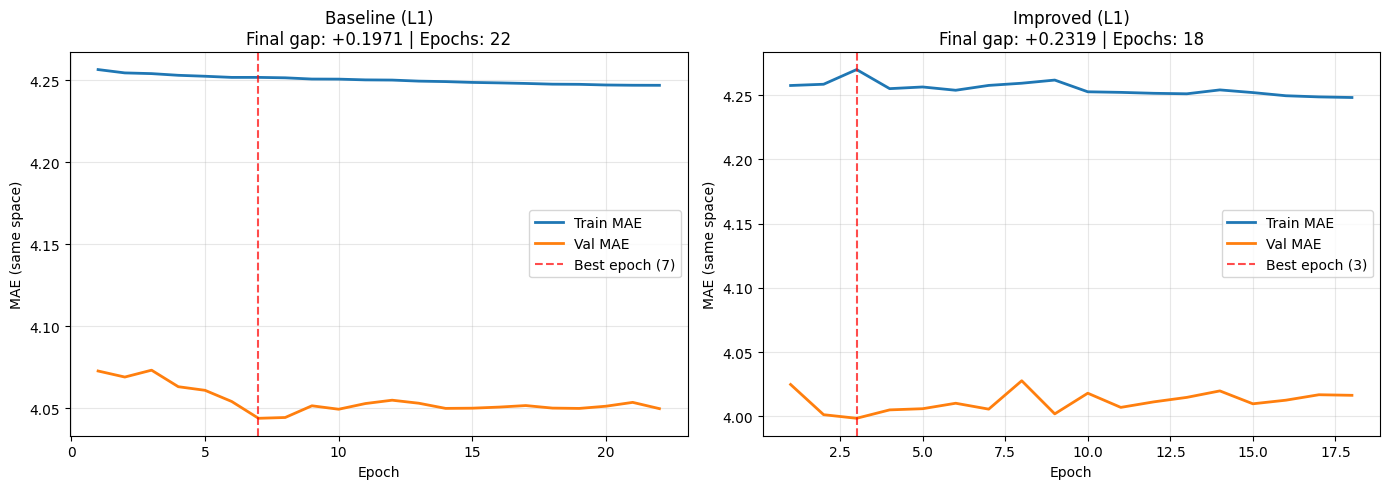

Baseline: 22 epochs, final train=4.2469, final val=4.0497
Improved: 18 epochs, final train=4.2482, final val=4.0163


In [ ]:
def train_and_eval_with_history(model, train_loader, val_loader, optimizer, is_improved):
    criterion = nn.L1Loss(reduction='none')
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_state = None
    best_metric = float("inf")
    epochs_without_improvement = 0

    history = {"train_mae": [], "val_mae": []}

    for epoch in range(1, MAX_EPOCHS + 1):
        # --- Training step ---
        model.train()
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            if is_improved:
                bx, by, bmask, bstatic, lengths = batch
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, lengths, bstatic)
                loss_m = criterion(logits, by)
                loss = loss_m[bmask].mean() if loss_m[bmask].numel() > 0 else 0*loss_m.sum()
            else:
                bx, bstatic, by, bmask = batch
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, bstatic)
                loss_m = criterion(logits, by)
                loss = loss_m[bmask].mean() if loss_m[bmask].numel() > 0 else 0*loss_m.sum()

            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        # --- Eval-mode MAE on train set ---
        model.eval()
        def compute_mae(loader):
            all_preds, all_targets, all_masks = [], [], []
            with torch.no_grad():
                for batch in loader:
                    if is_improved:
                        bx, by, bmask, bstatic, lengths = batch
                        bx, bstatic = bx.to(DEVICE), bstatic.to(DEVICE)
                        logits = model(bx, lengths, bstatic)
                    else:
                        bx, bstatic, by, bmask = batch
                        bx, bstatic = bx.to(DEVICE), bstatic.to(DEVICE)
                        logits = model(bx, bstatic)
                    all_preds.append(logits.cpu().numpy())
                    all_targets.append(by.numpy())
                    all_masks.append(bmask.numpy() if not is_improved else bmask.numpy())
            if not all_preds:
                return None
            y_pred = np.vstack(all_preds)
            y_true = np.vstack(all_targets)
            mask = np.vstack(all_masks).astype(bool)
            abs_err = np.abs(y_pred - y_true)
            if is_improved:
                y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
                y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
                abs_err = np.abs(y_pred - y_true)
            return np.mean(abs_err[mask]) if mask.any() else 0.0

        train_mae = compute_mae(train_loader)
        val_mae = compute_mae(val_loader)
        if train_mae is None or val_mae is None:
            break

        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)

        scheduler.step(val_mae)

        improved = val_mae < best_metric
        if improved:
            best_metric = val_mae
            best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_metric, history


best_l1_base = best_mtl_baselines["l1"]
best_l1_imp = best_mtl_imp["l1"]

set_seed(SEED)
model_base, train_loader_base, val_loader_base, _ = build_loaders_and_model(False, best_l1_base)
optimizer_base = torch.optim.Adam(model_base.parameters(), lr=best_l1_base["lr"], weight_decay=best_l1_base["weight_decay"])
_, _, hist_base = train_and_eval_with_history(model_base, train_loader_base, val_loader_base, optimizer_base, is_improved=False)

set_seed(SEED)
model_imp, train_loader_imp, val_loader_imp, _ = build_loaders_and_model(True, best_l1_imp)
optimizer_imp = torch.optim.Adam(model_imp.parameters(), lr=best_l1_imp["lr"], weight_decay=best_l1_imp["weight_decay"])
_, _, hist_imp = train_and_eval_with_history(model_imp, train_loader_imp, val_loader_imp, optimizer_imp, is_improved=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, hist) in zip(axes, [("Baseline (L1)", hist_base), ("Improved (L1)", hist_imp)]):
    epochs = range(1, len(hist["train_mae"]) + 1)
    ax.plot(epochs, hist["train_mae"], label="Train MAE", linewidth=2)
    ax.plot(epochs, hist["val_mae"], label="Val MAE", linewidth=2)
    best_epoch = np.argmin(hist["val_mae"]) + 1
    ax.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f"Best epoch ({best_epoch})")
    gap = hist["train_mae"][-1] - hist["val_mae"][-1]
    ax.set_title(f"{title}\nFinal gap: {gap:+.4f} | Epochs: {len(hist['train_mae'])}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE (same space)")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Baseline: {len(hist_base['train_mae'])} epochs, final train={hist_base['train_mae'][-1]:.4f}, final val={hist_base['val_mae'][-1]:.4f}")
print(f"Improved: {len(hist_imp['train_mae'])} epochs, final train={hist_imp['train_mae'][-1]:.4f}, final val={hist_imp['val_mae'][-1]:.4f}")

## Segmented Performance Analysis

In [ ]:
def evaluate_group_pipeline(is_improved, best_params_dict):
    group_results = []

    for l_type, params in best_params_dict.items():
        # Store individual run MAEs here to compute standard deviation
        group_run_maes = {grp: {t: [] for t in PREDICTION_TARGETS} for grp in ticker_groups.keys()}

        for run_idx in range(N_RUNS):
            set_seed(SEED + run_idx)
            # Re-train model for this run
            model, train_loader, val_loader, _ = build_loaders_and_model(is_improved, params)
            optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
            huber_delta = params.get("huber_delta", 1.0)
            model, _ = train_and_eval(model, train_loader, val_loader, optimizer, is_improved=is_improved, loss_type=l_type, huber_delta=huber_delta)

            for group_name, tickers in ticker_groups.items():
                if is_improved:
                    group_df = mtl_test_data_imp[mtl_test_data_imp['company'].isin(tickers)]
                    if group_df.empty: continue
                    group_ds = ImprovedYoYDatasetMTL(group_df, robust_scaler, selected_indices)
                    collate = collate_fn_improved_mtl
                else:
                    group_df = mtl_test_data[mtl_test_data['company'].isin(tickers)]
                    if group_df.empty: continue
                    group_ds = YoYSequenceDatasetMTL(group_df, max_seq_length, scaler)
                    collate = None

                loader = DataLoader(group_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
                metrics = evaluate_loader(model, loader, is_improved=is_improved)

                if metrics:
                    for target, val in metrics.items():
                        if target not in PREDICTION_TARGETS:
                            continue
                        group_run_maes[group_name][target].append(val)

        # Compute mean and std
        for group_name in ticker_groups.keys():
            for target in PREDICTION_TARGETS:
                if len(group_run_maes[group_name][target]) > 0:
                    maes = group_run_maes[group_name][target]
                    group_results.append({
                        "Loss": l_type.upper(),
                        "Group": group_name,
                        "Target": target,
                        "MAE (Mean)": np.mean(maes),
                        "Deviation": np.std(maes)
                    })

    return group_results

print("Evaluating Improved MTL across losses and groups...")
imp_group_stats = evaluate_group_pipeline(True, best_mtl_imp)

print("\nEvaluating Baseline MTL across losses and groups...")
base_group_stats = evaluate_group_pipeline(False, best_mtl_baselines)

df_imp_group = pd.DataFrame(imp_group_stats)
df_base_group = pd.DataFrame(base_group_stats)

if df_imp_group.empty and df_base_group.empty:
    print("\nWARNING: No grouped results. The global test set may not contain all ticker groups.")
    print("Consider using the dedicated per-group pipeline for Mid-cap and Small-cap analysis.")

print("\n--- Grouped MAE: Improved MTL ---")
if not df_imp_group.empty:
    display(df_imp_group.pivot_table(index=['Target', 'Loss'], columns='Group', values=['MAE (Mean)', 'Deviation']))
else:
    print("No data available for Improved MTL grouping.")

print("\n--- Grouped MAE: Baseline MTL ---")
if not df_base_group.empty:
    display(df_base_group.pivot_table(index=['Target', 'Loss'], columns='Group', values=['MAE (Mean)', 'Deviation']))
else:
    print("No data available for Baseline MTL grouping.")

Evaluating Improved MTL across losses and groups...

Evaluating Baseline MTL across losses and groups...

--- Grouped MAE: Improved MTL ---


Deviation                     MAE (Mean)                    
Group                  MIB   Mid-cap Small-cap        MIB   Mid-cap Small-cap
Target     Loss                                                              
EBITDA     HUBER  0.011169  0.037904  0.061822   2.526277  0.491688  1.149478
           L1     0.010872  0.023855  0.032590   2.521068  0.469182  1.128971
           MSE    0.014957  0.042241  0.049163   2.541583  0.530739  1.186753
Net_Income HUBER  0.014102  0.030322  0.042450   0.530427  2.110528  1.546726
           L1     0.022901  0.023967  0.030573   0.536231  2.102184  1.555229
           MSE    0.043495  0.022424  0.010123   0.568962  2.108641  1.521227
ROA        HUBER  0.010249  0.021236  0.029834   0.535175  2.062479  1.593213
           L1     0.026979  0.021323  0.015022   0.541197  2.054977  1.588466
           MSE    0.049971  0.026554  0.013660   0.576100  2.069947  1.575837


--- Grouped MAE: Baseline MTL ---


Deviation                     MAE (Mean)                    
Group                  MIB   Mid-cap Small-cap        MIB   Mid-cap Small-cap
Target     Loss                                                              
EBITDA     HUBER  0.032175  0.042117  0.030538   2.546925  0.520294  1.130841
           L1     0.028175  0.032328  0.036654   2.537053  0.489174  1.123703
           MSE    0.146901  0.150448  0.152273   2.692525  0.716243  1.362697
Net_Income HUBER  0.019460  0.025822  0.021215   0.542310  2.128294  1.533630
           L1     0.044592  0.021937  0.027379   0.545390  2.108051  1.541591
           MSE    0.043625  0.034520  0.035762   0.586404  2.128016  1.533966
ROA        HUBER  0.020957  0.021426  0.014493   0.562648  2.083750  1.582905
           L1     0.052770  0.027027  0.020724   0.569495  2.072242  1.582293
           MSE    0.049658  0.022936  0.013096   0.602174  2.082953  1.577117

## Directional Accuracy

In [ ]:
def calculate_directional_accuracy(model, loader, is_improved):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for batch in loader:
            if is_improved:
                bx, by, bmask, bstatic, lengths = batch
                logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
                all_masks.append(bmask.numpy())
            else:
                bx, bstatic, by, bmask = batch
                logits = model(bx.to(DEVICE), bstatic.to(DEVICE))
                all_masks.append(bmask.numpy())
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())

    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    mask = np.vstack(all_masks)

    accuracy_res = {}
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0: continue
        # Directional agreement: both positive or both negative
        correct_dir = (np.sign(y_pred[m, i]) == np.sign(y_true[m, i])).sum()
        accuracy_res[t] = correct_dir / m.sum()
    return accuracy_res

print("--- Directional Accuracy (Improved Pipeline) ---")
for l_type, params in best_mtl_imp.items():
    set_seed(SEED)
    model_imp, train_loader_imp, val_loader_imp, test_loader_imp = build_loaders_and_model(True, params)
    optimizer = torch.optim.Adam(model_imp.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    huber_delta = params.get("huber_delta", 1.0)
    model_imp, _ = train_and_eval(
        model_imp, train_loader_imp, val_loader_imp, optimizer,
        is_improved=True, loss_type=l_type, huber_delta=huber_delta
    )
    dir_acc = calculate_directional_accuracy(model_imp, test_loader_imp, True)
    print(f"[{l_type.upper()}] Directional Accuracy:", dir_acc)

--- Directional Accuracy (Improved Pipeline) ---
[L1] Directional Accuracy: {'EBITDA': np.float64(0.6319018404907976), 'Net_Income': np.float64(0.5198776758409785), 'ROA': np.float64(0.4617737003058104)}
[MSE] Directional Accuracy: {'EBITDA': np.float64(0.6380368098159509), 'Net_Income': np.float64(0.5229357798165137), 'ROA': np.float64(0.4892966360856269)}
[HUBER] Directional Accuracy: {'EBITDA': np.float64(0.6196319018404908), 'Net_Income': np.float64(0.5382262996941896), 'ROA': np.float64(0.45871559633027525)}


## Specialized Models by Market Cap

In [ ]:
def run_dedicated_pipeline(group_name, tickers, loss_type='l1'):
    print(f"\n--- Dedicated Pipeline: {group_name} ({loss_type.upper()}) ---")

    group_df = improved_data_df[improved_data_df['company'].isin(tickers)].copy()
    if group_df.empty:
        print(f"Skipping {group_name}: No data available.")
        return [], None

    try:
        g_train, g_val, g_test = split_by_year_dynamic(group_df)
    except ValueError as e:
        print(f"Skipping {group_name}: {e}")
        return [], None

    if g_train.empty:
        print(f"Skipping {group_name}: Training set is empty after the dynamic split.")
        return [], None

    if g_val.equals(g_test):
        print(f"WARNING: {group_name} has only 2 years. Validation and Test sets are identical.")
        print(f"  Results for {group_name} may not generalize. Treat as validation-only.")

    g_scaler = RobustScaler()
    g_train_windows = np.vstack([row[:, selected_indices] for row in g_train["window_data"]])
    g_scaler.fit(g_train_windows)

    g_mtl_train = extract_mtl_df(g_train)
    g_mtl_val = extract_mtl_df(g_val)
    g_mtl_test = extract_mtl_df(g_test)

    fixed_window_size = None  # Use full 365-day lookback (no truncation)

    def group_objective(trial):
        hidden_size = trial.suggest_categorical("hidden_size", [32, 64, 128, 256])
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)

        train_ds = ImprovedYoYDatasetMTL(g_mtl_train, g_scaler, selected_indices, window_size=fixed_window_size)
        val_ds = ImprovedYoYDatasetMTL(g_mtl_val, g_scaler, selected_indices, window_size=fixed_window_size)

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn_improved_mtl)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_improved_mtl)

        model = ImprovedShallowLSTM(
            input_size=len(selected_indices),
            hidden_size=hidden_size,
            num_targets=len(PREDICTION_TARGETS),
            dropout=dropout,
            static_dim=STATIC_DIM
        ).to(DEVICE)

        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

        _, best_metric = train_and_eval(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            is_improved=True,
            trial=trial,
            loss_type=loss_type
        )
        return best_metric

    pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=15)
    study = optuna.create_study(direction="minimize", study_name=f"mtl_imp_{group_name}", pruner=pruner)
    study.optimize(group_objective, n_trials=OPTUNA_TRIALS)

    best_params = study.best_trial.params
    print(f"Best Params for {group_name}: {best_params}\n")

    target_results = {t: [] for t in PREDICTION_TARGETS}

    for run_idx in range(N_RUNS):
        set_seed(SEED + run_idx)

        train_ds = ImprovedYoYDatasetMTL(g_mtl_train, g_scaler, selected_indices, window_size=fixed_window_size)
        val_ds = ImprovedYoYDatasetMTL(g_mtl_val, g_scaler, selected_indices, window_size=fixed_window_size)
        test_ds = ImprovedYoYDatasetMTL(g_mtl_test, g_scaler, selected_indices, window_size=fixed_window_size)

        train_loader = DataLoader(train_ds, batch_size=best_params["batch_size"], shuffle=True, collate_fn=collate_fn_improved_mtl)
        val_loader = DataLoader(val_ds, batch_size=best_params["batch_size"], shuffle=False, collate_fn=collate_fn_improved_mtl)
        test_loader = DataLoader(test_ds, batch_size=best_params["batch_size"], shuffle=False, collate_fn=collate_fn_improved_mtl)

        dropout_val = best_params.get("dropout", 0.2)

        model = ImprovedShallowLSTM(
            input_size=len(selected_indices),
            hidden_size=best_params["hidden_size"],
            num_targets=len(PREDICTION_TARGETS),
            dropout=dropout_val,
            static_dim=STATIC_DIM
        ).to(DEVICE)

        optimizer = torch.optim.Adam(model.parameters(), lr=best_params["lr"], weight_decay=best_params["weight_decay"])

        model, _ = train_and_eval(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            optimizer=optimizer,
            is_improved=True,
            trial=None,
            loss_type=loss_type
        )

        res = evaluate_loader(model, test_loader, True)

        if res:
            for target, val in res.items():
                if target not in PREDICTION_TARGETS:
                    continue
                target_results[target].append(val)

    group_stats = []

    for target in PREDICTION_TARGETS:
        if not target_results[target]:
            print(f"  NOTE: {target} has no valid data for {group_name}. Skipping.")
            continue

        avg_mae = np.mean(target_results[target])
        std_mae = np.std(target_results[target])

        group_stats.append({
            "Group": group_name,
            "Target": target,
            "Dedicated Test MAE": avg_mae,
            "Dedicated Deviation": std_mae
        })

    valid_means = [np.mean(target_results[t]) for t in PREDICTION_TARGETS if target_results[t]]
    if valid_means:
        total_mae = np.mean(valid_means)
        total_std = np.std(valid_means)

        print(f"{group_name} - Total Test MAE: {total_mae:.4f} ± {total_std:.4f}")

        group_stats.append({
            "Group": group_name,
            "Target": "TOTAL",
            "Dedicated Test MAE": total_mae,
            "Dedicated Deviation": total_std
        })

    return group_stats, best_params

dedicated_all_stats = []
dedicated_best_params = {}
for group_name, tickers in ticker_groups.items():
    stats, params = run_dedicated_pipeline(group_name, tickers, loss_type='l1')
    if params is not None:
        dedicated_best_params[group_name] = params
    if stats:
        dedicated_all_stats.extend(stats)

df_dedicated = pd.DataFrame(dedicated_all_stats)
pivot_result = df_dedicated.pivot(index='Target', columns='Group', values='Dedicated Test MAE')
print("\nNote: NaN indicates no valid data for that target/group combination.")
display(pivot_result.fillna("N/A"))


--- Dedicated Pipeline: MIB (L1) ---
Available years in dataset: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train: <= 2020 (758 samples)
Validation: 2021-2022 (166 samples)
Test: > 2022 (174 samples)


[I 2026-06-15 10:22:12,785] A new study created in memory with name: mtl_imp_MIB
[I 2026-06-15 10:22:23,016] Trial 0 finished with value: 1.3925260305404663 and parameters: {'hidden_size': 256, 'lr': 0.0015828430101379504, 'batch_size': 32, 'weight_decay': 7.181713128041071e-06, 'dropout': 0.43819902819554646}. Best is trial 0 with value: 1.3925260305404663.
[I 2026-06-15 10:22:31,629] Trial 1 finished with value: 1.4075956344604492 and parameters: {'hidden_size': 128, 'lr': 0.008825329982461565, 'batch_size': 64, 'weight_decay': 2.9322825660369388e-05, 'dropout': 0.24372600385103374}. Best is trial 0 with value: 1.3925260305404663.
[I 2026-06-15 10:22:43,691] Trial 2 finished with value: 1.4079509973526 and parameters: {'hidden_size': 128, 'lr': 0.0001516373758210153, 'batch_size': 16, 'weight_decay': 5.715366623235156e-05, 'dropout': 0.3698340204329378}. Best is trial 0 with value: 1.3925260305404663.
[I 2026-06-15 10:22:58,064] Trial 3 finished with value: 1.4560966491699219 and par

Best Params for MIB: {'hidden_size': 32, 'lr': 0.002754163079848199, 'batch_size': 64, 'weight_decay': 1.2190531686009464e-05, 'dropout': 0.37812674373873345}

MIB - Total Test MAE: 1.2131 ± 0.9348

--- Dedicated Pipeline: Mid-cap (L1) ---
Available years in dataset: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train: <= 2020 (1174 samples)
Validation: 2021-2022 (294 samples)
Test: > 2022 (315 samples)


[I 2026-06-15 10:28:30,381] A new study created in memory with name: mtl_imp_Mid-cap
[I 2026-06-15 10:28:36,702] Trial 0 finished with value: 1.294884443283081 and parameters: {'hidden_size': 256, 'lr': 0.009720660439419725, 'batch_size': 16, 'weight_decay': 8.115794173570031e-05, 'dropout': 0.24385542223303147}. Best is trial 0 with value: 1.294884443283081.
[I 2026-06-15 10:28:43,838] Trial 1 finished with value: 1.3061026334762573 and parameters: {'hidden_size': 128, 'lr': 0.002480240181441189, 'batch_size': 16, 'weight_decay': 5.2918886961001275e-06, 'dropout': 0.25617194377894165}. Best is trial 0 with value: 1.294884443283081.
[I 2026-06-15 10:28:49,132] Trial 2 finished with value: 1.3010683059692383 and parameters: {'hidden_size': 256, 'lr': 0.0058241475975962615, 'batch_size': 64, 'weight_decay': 0.0008767514962245073, 'dropout': 0.19759141288648174}. Best is trial 0 with value: 1.294884443283081.
[I 2026-06-15 10:28:55,875] Trial 3 finished with value: 1.2953815460205078 and 

Best Params for Mid-cap: {'hidden_size': 128, 'lr': 0.006162808003917426, 'batch_size': 16, 'weight_decay': 0.0009120019993657931, 'dropout': 0.3102066299770276}

Mid-cap - Total Test MAE: 1.5558 ± 0.7595

--- Dedicated Pipeline: Small-cap (L1) ---
Available years in dataset: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train: <= 2020 (1983 samples)
Validation: 2021-2022 (463 samples)
Test: > 2022 (485 samples)


[I 2026-06-15 10:37:55,518] A new study created in memory with name: mtl_imp_Small-cap
[I 2026-06-15 10:38:14,531] Trial 0 finished with value: 6.7016730308532715 and parameters: {'hidden_size': 64, 'lr': 0.0006587483033327497, 'batch_size': 64, 'weight_decay': 0.0002956655675997911, 'dropout': 0.48164222276847946}. Best is trial 0 with value: 6.7016730308532715.
[I 2026-06-15 10:38:24,895] Trial 1 finished with value: 6.68011474609375 and parameters: {'hidden_size': 128, 'lr': 0.0012008846032305928, 'batch_size': 64, 'weight_decay': 1.7151165936740303e-05, 'dropout': 0.3937935536723789}. Best is trial 1 with value: 6.68011474609375.
[I 2026-06-15 10:38:33,224] Trial 2 finished with value: 6.677561283111572 and parameters: {'hidden_size': 256, 'lr': 0.0029477753322042165, 'batch_size': 64, 'weight_decay': 2.813190417835396e-05, 'dropout': 0.2914255091917741}. Best is trial 2 with value: 6.677561283111572.
[I 2026-06-15 10:38:42,724] Trial 3 finished with value: 6.6554388999938965 and p

Best Params for Small-cap: {'hidden_size': 32, 'lr': 0.008112408141838737, 'batch_size': 16, 'weight_decay': 1.0432514366986697e-06, 'dropout': 0.26738444726619137}

Small-cap - Total Test MAE: 1.4147 ± 0.2079

Note: NaN indicates no valid data for that target/group combination.


Group,MIB,Mid-cap,Small-cap
Target,,,
EBITDA,2.535133,0.482243,1.121865
Net_Income,0.548381,2.122047,1.538482
ROA,0.555687,2.063257,1.583612
TOTAL,1.213067,1.555849,1.414653


In [13]:
results = []
fixed_window_size = None  # Use full 365-day lookback (no truncation)

for group_name, tickers in ticker_groups.items():

    print("\n" + "=" * 60)
    print(f"Training Final Model for: {group_name}")
    print("=" * 60)

    params = dedicated_best_params[group_name]

    set_seed(42)

    group_df = improved_data_df[
        improved_data_df["company"].isin(tickers)
    ].copy()

    if group_df.empty:
        print(f"Skipping {group_name}: No data available.")
        continue

    # Use the dynamic split to prevent empty Validation/Test sets
    try:
        g_train, g_val, g_test = split_by_year_dynamic(group_df)
    except ValueError as e:
        print(f"Skipping {group_name}: {e}")
        continue

    if g_train.empty:
        print(f"Skipping {group_name}: Training set is empty.")
        continue

    scaler = RobustScaler()

    train_windows = np.vstack([
        row[:, selected_indices]
        for row in g_train["window_data"]
    ])

    scaler.fit(train_windows)

    # Pass fixed_window_size to avoid the TypeError
    train_ds = ImprovedYoYDatasetMTL(
        extract_mtl_df(g_train),
        scaler,
        selected_indices,
        window_size=fixed_window_size
    )

    val_ds = ImprovedYoYDatasetMTL(
        extract_mtl_df(g_val),
        scaler,
        selected_indices,
        window_size=fixed_window_size
    )

    test_ds = ImprovedYoYDatasetMTL(
        extract_mtl_df(g_test),
        scaler,
        selected_indices,
        window_size=fixed_window_size
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=params["batch_size"],
        shuffle=True,
        collate_fn=collate_fn_improved_mtl
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=params["batch_size"],
        shuffle=False,
        collate_fn=collate_fn_improved_mtl
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=params["batch_size"],
        shuffle=False,
        collate_fn=collate_fn_improved_mtl
    )

    # Initialize the single-layer architecture
    model = ImprovedShallowLSTM(
        input_size=len(selected_indices),
        hidden_size=params["hidden_size"],
        num_targets=len(PREDICTION_TARGETS),
        dropout=params["dropout"],
        static_dim=STATIC_DIM
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"]
    )

    model, _ = train_and_eval(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        is_improved=True,
        trial=None,
        loss_type='l1'
    )

    print(f"\nTEST RESULTS FOR {group_name}")
    mae, rmse = evaluate_real_metrics(
        model,
        test_loader,
        DEVICE
    )

    n_samples = len(test_ds)

    results.append({
        "Group": group_name,
        "MAE": mae,
        "RMSE": rmse,
        "N": n_samples
    })

df_results = pd.DataFrame(results)

print("\n")
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(df_results)

# Safely calculate weighted metrics only if we have results
if not df_results.empty and df_results["N"].sum() > 0:
    weighted_mae = (
        (df_results["MAE"] * df_results["N"]).sum()
        / df_results["N"].sum()
    )

    weighted_rmse = (
        (df_results["RMSE"] * df_results["N"]).sum()
        / df_results["N"].sum()
    )

    print(f"\nWeighted MAE: {weighted_mae:.4f}")
    print(f"Weighted RMSE: {weighted_rmse:.4f}")
else:
    print("\nNo valid results to compute weighted metrics.")


Training Final Model for: MIB
Available years in dataset: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train: <= 2020 (758 samples)
Validation: 2021-2022 (166 samples)
Test: > 2022 (174 samples)

TEST RESULTS FOR MIB
Test MAE  (Real Scale): 1.2074
Test RMSE (Real Scale): 9.9677

Training Final Model for: Mid-cap
Available years in dataset: [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train: <= 2020 (1174 samples)
Validation: 2021-2022 (294 samples)
Test: > 2022 (315 samples)

TEST RESULTS FOR Mid-cap
Test MAE  (Real Scale): 1.6024
Test RMSE (Real Scale): 10.6255

Training Final Model for: Small-cap
A